#  Analysis of Activity Distribution

To better understand our data, it is useful to visualize how the different activities are distributed among the training, validation, and test sets.

In [ ]:
#New split
train_subjects = [2, 3, 10, 12, 13, 14, 16, 17, 18, 21]
val_subjects = [1, 5, 6, 7, 11, 15, 20]
test_subjects = [4, 8, 9, 19, 22]   

In [ ]:
#Old split :
train_subjects = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
val_subjects = [12, 13, 14, 15, 16]
test_subjects = [17, 18, 19, 20, 21, 22]

In [ ]:
df_quat = pd.read_csv('sensor_data_quaternions.csv')

--- Distribution of Total Samples by Activity ---


Split,Test,Train,Validation
ActivityID,,,
0,1306,1316,0
1,25682,51589,33326
2,2567,6176,9835
3,9640,19049,13201
4,1656,4608,3048
5,1485,3069,2925
6,7820,20289,13751
7,11875,26284,21285



--- Distribution of FoG Samples by Activity ---


Split,Test,Train,Validation
ActivityID,,,
0,0,0,0
1,1519,1872,774
2,0,0,0
3,96,1181,60
4,0,0,0
5,0,66,12
6,3056,9197,8237
7,7501,13351,9956



--- Distribution in % of Total Samples by Activity ---


Split,Test,Train,Validation
ActivityID,,,
0,2.11,0.99,0.00
1,41.40,38.97,34.23
2,4.14,4.67,10.10
3,15.54,14.39,13.56
4,2.67,3.48,3.13
5,2.39,2.32,3.00
6,12.61,15.33,14.12
7,19.14,19.85,21.86



--- Distribution in % of FoG Samples by Activity ---


Split,Test,Train,Validation
ActivityID,,,
0,0.00,0.00,0.00
1,12.48,7.29,4.07
2,0.00,0.00,0.00
3,0.79,4.60,0.32
4,0.00,0.00,0.00
5,0.00,0.26,0.06
6,25.11,35.83,43.26
7,61.63,52.02,52.29


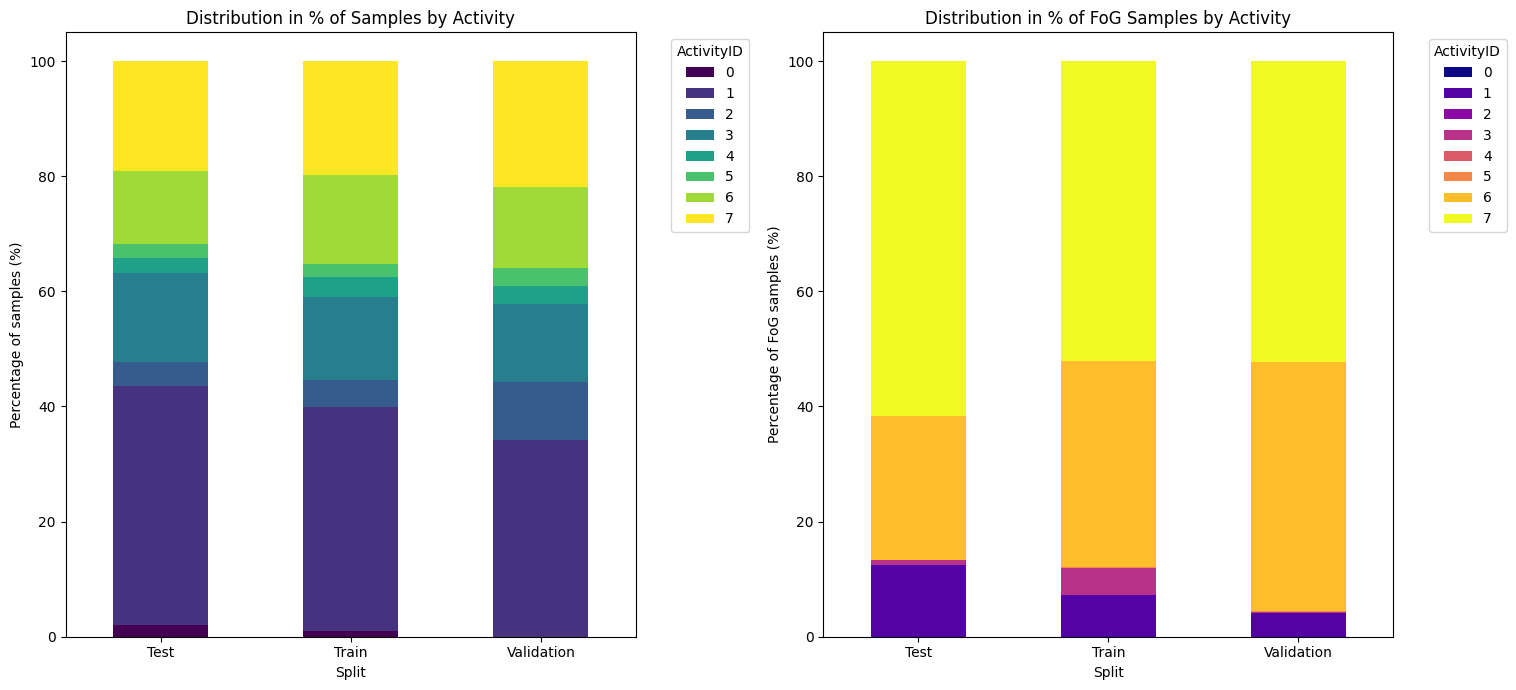

In [27]:
def analyze_activity_distribution(df, subjects_dict):
    """Displays the distribution of activities and FoG episodes for each split."""
    
    activity_col = 'activity' # Assume the column is named 'activity'
    if activity_col not in df.columns:
        print(f"Error: Column '{activity_col}' does not exist in the DataFrame.")
        return

    results = []
    for split_name, subjects in subjects_dict.items():
        split_df = df[df['subjectID'].isin(subjects)]
        
        if split_df.empty:
            continue
            
        activity_counts = split_df[activity_col].value_counts().sort_index()
        fog_counts = split_df[split_df['fog'] == 1][activity_col].value_counts().sort_index()
        
        split_summary = pd.DataFrame({
            'Total Samples': activity_counts,
            'FoG Samples': fog_counts
        }).fillna(0).astype(int)
        
        split_summary['Split'] = split_name
        split_summary['ActivityID'] = split_summary.index
        results.append(split_summary)

    if not results:
        print("No data found for the specified subjects.")
        return

    full_summary = pd.concat(results)
    
    # --- Absolute Count Tables ---
    pivot_total = full_summary.pivot(index='ActivityID', columns='Split', values='Total Samples').fillna(0).astype(int)
    pivot_fog = full_summary.pivot(index='ActivityID', columns='Split', values='FoG Samples').fillna(0).astype(int)
    
    print("--- Distribution of Total Samples by Activity ---")
    display(pivot_total)
    
    print("\n--- Distribution of FoG Samples by Activity ---")
    display(pivot_fog)

    # --- Percentage Tables ---
    # Percentage relative to the total of each split
    pivot_total_pct = pivot_total.div(pivot_total.sum(axis=0), axis=1) * 100
    pivot_fog_pct = pivot_fog.div(pivot_fog.sum(axis=0), axis=1) * 100

    print("\n--- Distribution in % of Total Samples by Activity ---")
    display(pivot_total_pct.round(2))

    print("\n--- Distribution in % of FoG Samples by Activity ---")
    display(pivot_fog_pct.round(2))
    
    # --- Percentage Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    pivot_total_pct.T.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
    axes[0].set_title('Distribution in % of Samples by Activity')
    axes[0].set_ylabel('Percentage of samples (%)')
    axes[0].set_xlabel('Split')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='ActivityID', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    pivot_fog_pct.T.plot(kind='bar', stacked=True, ax=axes[1], colormap='plasma')
    axes[1].set_title('Distribution in % of FoG Samples by Activity')
    axes[1].set_ylabel('Percentage of FoG samples (%)')
    axes[1].set_xlabel('Split')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='ActivityID', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust to make room for the legend
    plt.show()


# Dictionary of subject splits
subject_splits = {
    'Train': train_subjects,
    'Validation': val_subjects,
    'Test': test_subjects
}

# Run the analysis
analyze_activity_distribution(df_quat, subject_splits)

# 7. Analysis of Subject Contribution to FoG in Difficult Activities

Following our analysis, we know that the distribution of FoG is the main problem. To create better splits, we need to identify which subjects are the biggest "providers" of FoG for activities 1 and 3.

--- Contributeurs de Fenêtres de FoG pour les Activités [1, 3] ---


activity,1,3,Total FoG Windows
subjectID,,,
2,62,39,101
19,46,3,49
20,13,0,13
11,6,1,7
15,7,0,7
9,3,0,3
13,2,0,2
3,0,1,1


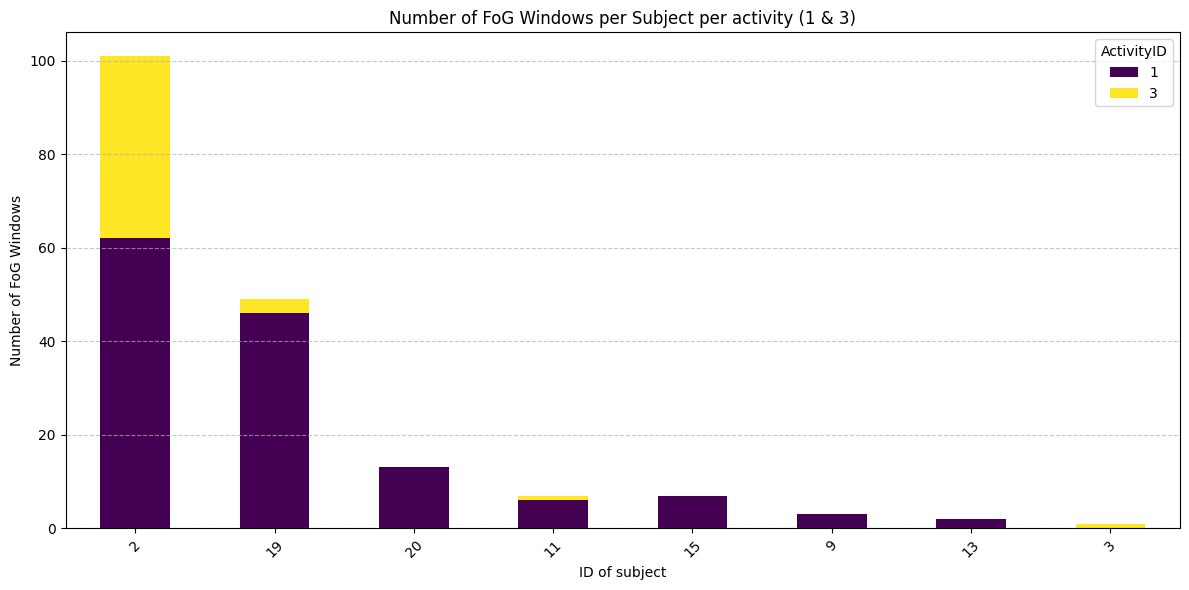

In [29]:

def analyze_fog_contributors_by_window(df, activity_ids, w=2, o=0.75, fs=60):
    """
    Analyse quels sujets contribuent le plus aux *fenêtres* de FoG pour des activités spécifiques.
    """
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    
    all_windows_data = []

    # 1. Générer toutes les fenêtres pour tous les sujets
    for sub_id in df['subjectID'].unique():
        sub_df = df[df['subjectID'] == sub_id].reset_index(drop=True)
        if sub_df.empty:
            continue

        labels = sub_df['fog'].values
        acts = sub_df['activity'].values

        for i in range(0, len(sub_df) - win_size, step):
            # Déterminer le label et l'activité de la fenêtre
            y_mode = pd.Series(labels[i:i + win_size]).mode()[0]
            a_mode = pd.Series(acts[i:i + win_size]).mode()[0]
            
            all_windows_data.append({
                'subjectID': sub_id,
                'activity': int(a_mode),
                'fog': int(y_mode)
            })

    # 2. Créer un DataFrame à partir des fenêtres générées
    windows_df = pd.DataFrame(all_windows_data)
    
    # 3. Filtrer pour les fenêtres de FoG dans les activités cibles
    fog_windows_df = windows_df[
        (windows_df['fog'] == 1) & 
        (windows_df['activity'].isin(activity_ids))
    ]
    
    if fog_windows_df.empty:
        print(f"Aucune *fenêtre* de FoG trouvée pour les activités {activity_ids}.")
        return

    # 4. Compter les contributions par sujet et par activité
    contributors = fog_windows_df.groupby(['subjectID', 'activity']).size().unstack(fill_value=0)
    
    # Ajouter une colonne 'Total'
    contributors['Total FoG Windows'] = contributors.sum(axis=1)
    
    # Trier par le total
    contributors = contributors.sort_values('Total FoG Windows', ascending=False)

    print(f"--- Contributeurs de Fenêtres de FoG pour les Activités {activity_ids} ---")
    display(contributors)

    # 5. Visualisation
    contributors.drop('Total FoG Windows', axis=1).plot(
        kind='bar', 
        stacked=True, 
        figsize=(12, 6),
        colormap='viridis'
    )
    plt.title('Number of FoG Windows per Subject per activity (1 & 3)')
    plt.xlabel('ID of subject')
    plt.ylabel('Number of FoG Windows')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='ActivityID')
    plt.tight_layout()
    plt.show()

# Lancer l'analyse pour les activités 1 et 3
analyze_fog_contributors_by_window(df_quat, [1, 3])
